# Race Infos Analysis

This notebook profiles the raw race-level datasets in `data/raw/race_header` and `data/raw/race_info`.

Because both folders contain a very large number of tiny CSV files, the notebook defaults to a reproducible random sample of races. That keeps the analysis fast while still surfacing the main data quality issues: missing values, malformed fields, structural inconsistencies, and numeric outliers.


In [1]:
from pathlib import Path
import random

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 200)

DATA_DIR = Path("../data/raw")
RACE_HEADER_DIR = DATA_DIR / "race_header"
RACE_INFO_DIR = DATA_DIR / "race_info"

SAMPLE_N = 5_000
RANDOM_SEED = 42


In [2]:
def sample_csv_files(folder: Path, sample_n: int, random_seed: int = 42):
    files = sorted(folder.glob("*.csv"))
    rng = random.Random(random_seed)
    if sample_n is None or sample_n >= len(files):
        return files
    return rng.sample(files, sample_n)


def load_race_header_sample(folder: Path, sample_n: int, random_seed: int = 42) -> pd.DataFrame:
    files = sample_csv_files(folder, sample_n, random_seed)
    frames = []
    for path in files:
        df = pd.read_csv(path)
        df["source_file"] = path.name
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def load_race_info_sample(folder: Path, sample_n: int, random_seed: int = 42):
    files = sample_csv_files(folder, sample_n, random_seed)
    frames = []
    file_stats = []
    for path in files:
        df = pd.read_csv(path)
        df["source_file"] = path.name
        frames.append(df)

        trap_values = pd.to_numeric(df.get("trapNumber"), errors="coerce")
        dog_values = df.get("dogId")
        file_stats.append({
            "source_file": path.name,
            "rows": len(df),
            "has_results_columns": "resultPosition" in df.columns,
            "distinct_traps": trap_values.nunique(dropna=True),
            "distinct_dogs": dog_values.nunique(dropna=True) if dog_values is not None else np.nan,
            "missing_traps": sorted(set(range(1, 7)) - set(trap_values.dropna().astype(int))) if "trapNumber" in df.columns else [],
        })

    return pd.concat(frames, ignore_index=True), pd.DataFrame(file_stats)


In [5]:
race_header = load_race_header_sample(RACE_HEADER_DIR, SAMPLE_N, RANDOM_SEED)
race_info, race_info_file_stats = load_race_info_sample(RACE_INFO_DIR, SAMPLE_N, RANDOM_SEED)

print(f"Header sample shape: {race_header.shape}")
print(f"Info sample shape:   {race_info.shape}")
print(f"Sampled races:       {race_info_file_stats.shape[0]:,}")

race_header.head()


Header sample shape: (5000, 15)
Info sample shape:   (30000, 25)
Sampled races:       5,000


,raceTime,raceDate,raceId,raceTitle,raceNumber,raceType,raceHandicap,raceClass,raceDistance,racePrizes,raceGoing,raceForecast,raceTricast,meeting_Id,source_file
0,18:48:00,16/05/2014,23211,NaN,2,Flat,False,A3,500.0,1st £114 | Others £28 | Race Total £254,NaN,(4-3) £26.94,(4-3-2) £63.76,287010,23211.csv
1,10:48:00,06/08/2024,1059379,INTERTRACK OXFORD vs SUFFOLK DOWNS,2,Flat,False,IT,450.0,1st £120 | Others £40 Race Total £320,-20.0,(5-3) £16.82,(5-3-2) £73.93,415050,1059379.csv
2,14:57:00,17/11/2014,52710,NaN,3,Flat,False,A3,480.0,NaN,-30.0,(4-6) £27.16,(4-6-5) £74.05,293703,52710.csv
3,20:51:00,13/09/2018,478706,5TH LEG PICK 6 JACKPOT,10,Flat,False,A1,462.0,1st £125 | Others £37 | Race Total £310,20.0,(6-2) £31.55,(6-2-3) £80.51,342636,478706.csv
4,12:54:00,11/05/2018,439829,NaN,10,Flat,False,A8,380.0,1st £110 | 2nd £45 | Others £40 | Race Total £315,20.0,(4-3) £15.71,(4-3-1) £68.58,338262,439829.csv


In [8]:
race_info.head()

,trapNumber,trapHandicap,dogId,dogName,dogSire,dogDam,dogBorn,dogColour,dogSex,dogSeason,trainerName,ownerName,SP,resultPosition,resultMarketPos,resultMarketCnt,resultPriceNumerator,resultPriceDenominator,resultBtnDistance,resultSectionalTime,resultComment,resultRunTime,resultDogWeight,resultAdjustedTime,source_file
0,4,NaN,421692,Salacres Biscuit,Burnpark Champ,Rathea Lass,Jun-2011,f,d,NaN,P H Harnden,Mr P H Harnden,4/1,1.0,3.0,2.0,4.0,1.0,NaN,5.30,DispLdFrRnIn,30.78,35.0,30.78,23211.csv
1,3,NaN,391014,At The Limit,Crash,On The River,Aug-2009,bk,d,NaN,E Saville,Mr S R Miller,9/2,2.0,5.0,1.0,9.0,2.0,HD,5.24,"Ld3-RnIn,DispLd",30.80,32.1,30.80,23211.csv
2,2,NaN,433420,Tynwald Movie,Makeshift,Ahavoher Rachel,May-2012,bkw,b,Suppressed,M T Munslow,Mr M T Munslow,9/4F,3.0,1.0,1.0,9.0,4.0,3/4,5.35,Crd3,30.86,29.0,30.86,23211.csv
3,5,NaN,430674,Pointless Rebo,Ballymac Rebound,Darkdesert Oasis,May-2012,bd,d,NaN,J Gray,Ms R Fell,5/2,4.0,2.0,1.0,5.0,2.0,3/4,5.27,"ClrRun,Mid",30.92,30.5,30.92,23211.csv
4,1,NaN,430627,Gateway Kirsty,Blackstone Gene,Society Duchess,Apr-2011,f,b,06.Au.16,L Cook,Mr B A Fitzpatrick,4/1,5.0,3.0,2.0,4.0,1.0,1 1/4,5.40,Crd1,31.02,25.9,31.02,23211.csv


## What this sample already shows

Using `SAMPLE_N = 5_000` races, a few patterns stand out quickly:

- `race_header` is one row per file, while `race_info` is usually six rows per file.
- A small number of `race_info` files do not contain result columns at all, which likely corresponds to races without recorded outcomes yet.
- `raceTitle`, `dogSeason`, `trapHandicap`, and some result fields have substantial missingness.
- Some numeric fields contain suspicious sentinel-like values such as `0` for `resultPosition`, `resultSectionalTime`, or `resultDogWeight`.
- A small tail of extremely low or high run times exists and should be checked against race distance before modeling.


In [4]:
def missingness_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "n_unique": df.nunique(dropna=True),
        "dtype": df.dtypes.astype(str),
    })
    return summary.sort_values(["missing_pct", "missing_count"], ascending=False)

header_missing = missingness_table(race_header)
info_missing = missingness_table(race_info)

header_missing.head(15)


,missing_count,missing_pct,n_unique,dtype
raceTitle,3029,60.58,1146,object
raceGoing,809,16.18,37,float64
racePrizes,260,5.20,995,object
raceTricast,186,3.72,4576,object
raceForecast,44,0.88,4812,object
raceTime,0,0.00,549,str
raceDate,0,0.00,2764,str
raceId,0,0.00,5000,int64
raceNumber,0,0.00,16,int64
raceType,0,0.00,2,str


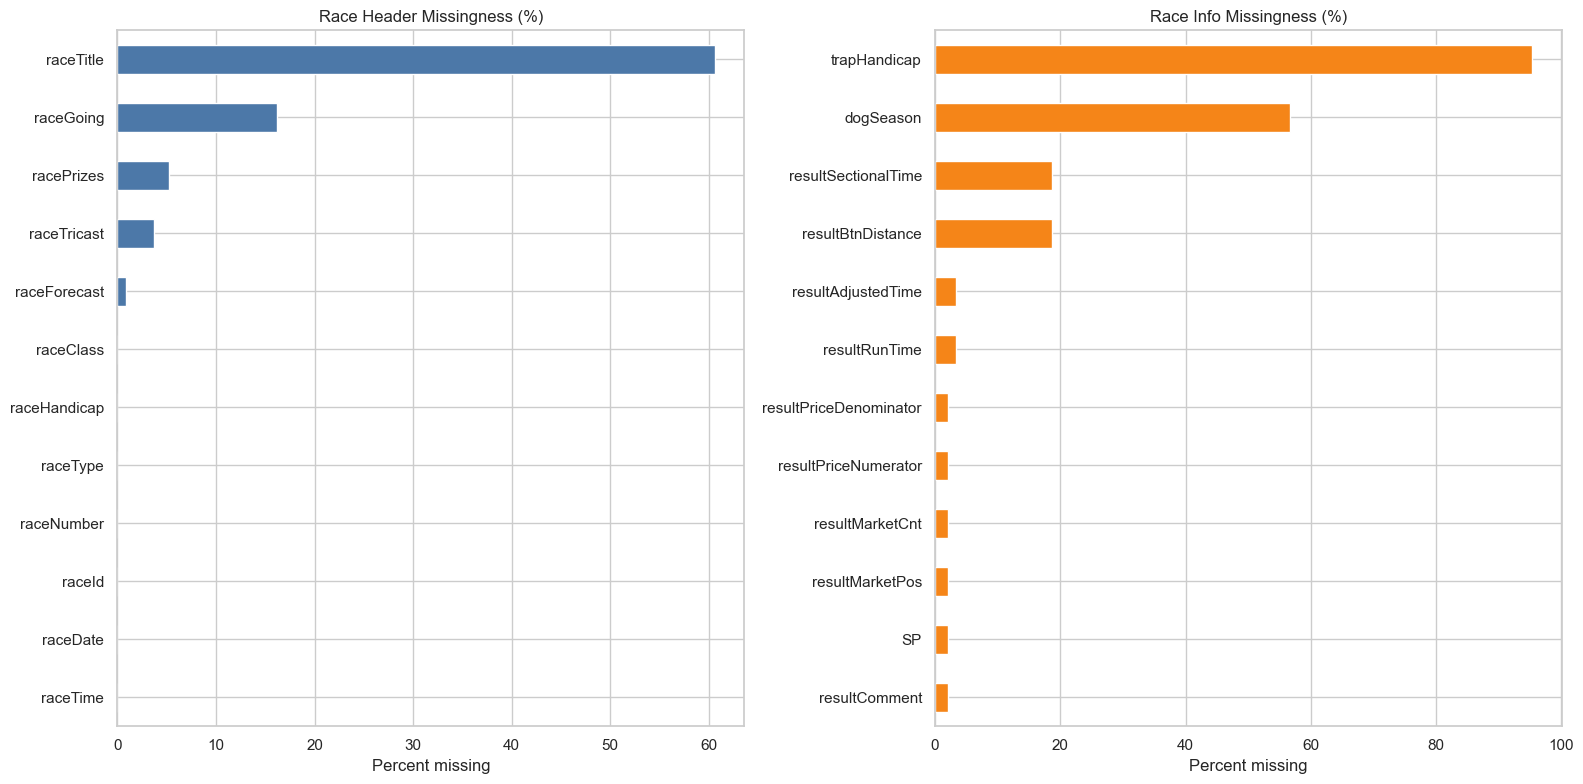

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

header_missing.head(12).sort_values("missing_pct").plot(
    kind="barh", y="missing_pct", ax=axes[0], legend=False, color="#4C78A8"
)
axes[0].set_title("Race Header Missingness (%)")
axes[0].set_xlabel("Percent missing")

info_missing.head(12).sort_values("missing_pct").plot(
    kind="barh", y="missing_pct", ax=axes[1], legend=False, color="#F58518"
)
axes[1].set_title("Race Info Missingness (%)")
axes[1].set_xlabel("Percent missing")

plt.tight_layout()


In [6]:
header_profile = {
    "sample_rows": len(race_header),
    "date_parse_failures": int(pd.to_datetime(race_header["raceDate"], format="%d/%m/%Y", errors="coerce").isna().sum()),
    "time_parse_failures": int(pd.to_datetime(race_header["raceTime"], format="%H:%M:%S", errors="coerce").isna().sum()),
    "duplicate_race_ids": int(race_header["raceId"].duplicated().sum()),
    "missing_race_going_pct": float(race_header["raceGoing"].isna().mean() * 100),
}

header_profile


{'sample_rows': 5000,
 'date_parse_failures': 0,
 'time_parse_failures': 0,
 'duplicate_race_ids': 0,
 'missing_race_going_pct': 16.18}

In [7]:
header_numeric_cols = ["raceDistance", "raceNumber", "meeting_Id"]
race_header[header_numeric_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
raceDistance,5000.0,446.4052,83.642914,220.0,238.00,265.00,470.0,540.0,660.00,912.0
raceNumber,5000.0,6.8532,3.651673,1.0,1.00,1.00,7.0,13.0,14.00,16.0
meeting_Id,5000.0,349432.9770,38310.682793,282560.0,284595.89,290374.25,348404.5,412053.6,424891.54,427737.0


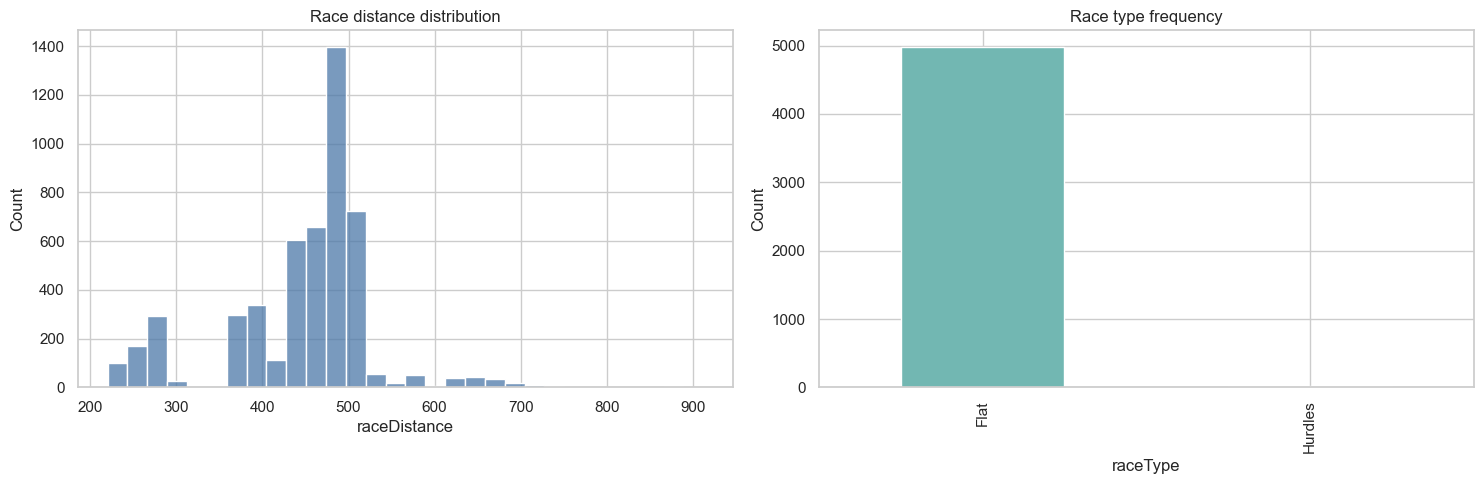

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(race_header["raceDistance"], bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_title("Race distance distribution")

race_header["raceType"].astype("string").value_counts(dropna=False).plot(
    kind="bar", ax=axes[1], color="#72B7B2"
)
axes[1].set_title("Race type frequency")
axes[1].set_ylabel("Count")

plt.tight_layout()


In [9]:
header_anomalies = pd.DataFrame({
    "raceClass": race_header["raceClass"].astype("string"),
    "raceGoing": pd.to_numeric(race_header["raceGoing"], errors="coerce"),
    "raceDistance": pd.to_numeric(race_header["raceDistance"], errors="coerce"),
})

print("Top race classes")
display(header_anomalies["raceClass"].value_counts(dropna=False).head(15))
print("\nRace going values")
display(header_anomalies["raceGoing"].value_counts(dropna=False).head(15))
print("\nLongest sampled races")
display(race_header.nlargest(10, "raceDistance")[["source_file", "raceDate", "raceType", "raceClass", "raceDistance", "raceGoing"]])


Top race classes


raceClass
A5     518
A4     511
A6     502
A3     452
A7     423
A2     352
OR     348
A8     296
A1     229
HP     227
D3     167
A9     152
D4     145
D2     138
A10     73
Name: count, dtype: Int64


Race going values


raceGoing
 0.0     1334
 NaN      809
 10.0     637
-10.0     505
 20.0     402
-20.0     400
-30.0     199
 30.0     168
-40.0      83
 40.0      59
 5.0       54
-5.0       51
-50.0      47
-15.0      46
 50.0      36
Name: count, dtype: int64


Longest sampled races


,source_file,raceDate,raceType,raceClass,raceDistance,raceGoing
390,780899.csv,10/10/2021,Flat,OR,912.0,60.0
2422,370545.csv,26/09/2017,Flat,OR,874.0,80.0
2445,599345.csv,30/11/2019,Flat,OR,874.0,NaN
4819,374411.csv,07/10/2017,Flat,M1,874.0,40.0
4938,380932.csv,28/10/2017,Flat,M2,874.0,40.0
497,523543.csv,22/02/2019,Flat,OR,750.0,0.0
1327,182330.csv,13/01/2016,Flat,OR,750.0,50.0
2589,321084.csv,14/04/2017,Flat,OR,750.0,30.0
3301,225941.csv,03/06/2016,Flat,OR,750.0,0.0
3406,215427.csv,30/04/2016,Flat,E2,750.0,-30.0


In [10]:
trap = pd.to_numeric(race_info["trapNumber"], errors="coerce")
result_position = pd.to_numeric(race_info.get("resultPosition"), errors="coerce")
sectional_time = pd.to_numeric(race_info.get("resultSectionalTime"), errors="coerce")
run_time = pd.to_numeric(race_info.get("resultRunTime"), errors="coerce")
dog_weight = pd.to_numeric(race_info.get("resultDogWeight"), errors="coerce")
adjusted_time = pd.to_numeric(race_info.get("resultAdjustedTime"), errors="coerce")
dog_born = pd.to_datetime(race_info["dogBorn"], format="%b-%Y", errors="coerce")

info_profile = {
    "sample_rows": len(race_info),
    "sample_races": race_info_file_stats.shape[0],
    "files_without_results_columns": int((~race_info_file_stats["has_results_columns"]).sum()),
    "rows_not_equal_to_6": int((race_info_file_stats["rows"] != 6).sum()),
    "races_missing_traps": int(race_info_file_stats["missing_traps"].astype(bool).sum()),
    "trap_out_of_range": int(((trap < 1) | (trap > 6)).fillna(False).sum()),
    "dogBorn_parse_failures": int(dog_born.isna().sum()),
    "missing_dogSex": int(race_info["dogSex"].isna().sum()),
    "resultPosition_zero": int((result_position == 0).fillna(False).sum()),
    "resultPosition_missing": int(result_position.isna().sum()),
    "sectionalTime_zero": int((sectional_time == 0).fillna(False).sum()),
    "dogWeight_zero": int((dog_weight == 0).fillna(False).sum()),
    "runTime_lt_15": int((run_time < 15).fillna(False).sum()),
    "runTime_gt_45": int((run_time > 45).fillna(False).sum()),
    "adjusted_vs_runtime_abs_diff_gt_1": int(((adjusted_time - run_time).abs() > 1).fillna(False).sum()),
}

info_profile


{'sample_rows': 30000,
 'sample_races': 5000,
 'files_without_results_columns': 25,
 'rows_not_equal_to_6': 0,
 'races_missing_traps': 0,
 'trap_out_of_range': 0,
 'dogBorn_parse_failures': 15,
 'missing_dogSex': 15,
 'resultPosition_zero': 110,
 'resultPosition_missing': 528,
 'sectionalTime_zero': 8,
 'dogWeight_zero': 16,
 'runTime_lt_15': 46,
 'runTime_gt_45': 95,
 'adjusted_vs_runtime_abs_diff_gt_1': 211}

In [11]:
race_info_file_stats.describe(include="all")


,source_file,rows,has_results_columns,distinct_traps,distinct_dogs,missing_traps
count,5000,5000.0,5000,5000.0,5000.000000,5000
unique,5000,NaN,2,NaN,NaN,1
top,23211.csv,NaN,True,NaN,NaN,[]
freq,1,NaN,4975,NaN,NaN,5000
mean,NaN,6.0,NaN,6.0,5.997000,NaN
std,NaN,0.0,NaN,0.0,0.054696,NaN
min,NaN,6.0,NaN,6.0,5.000000,NaN
25%,NaN,6.0,NaN,6.0,6.000000,NaN
50%,NaN,6.0,NaN,6.0,6.000000,NaN
75%,NaN,6.0,NaN,6.0,6.000000,NaN


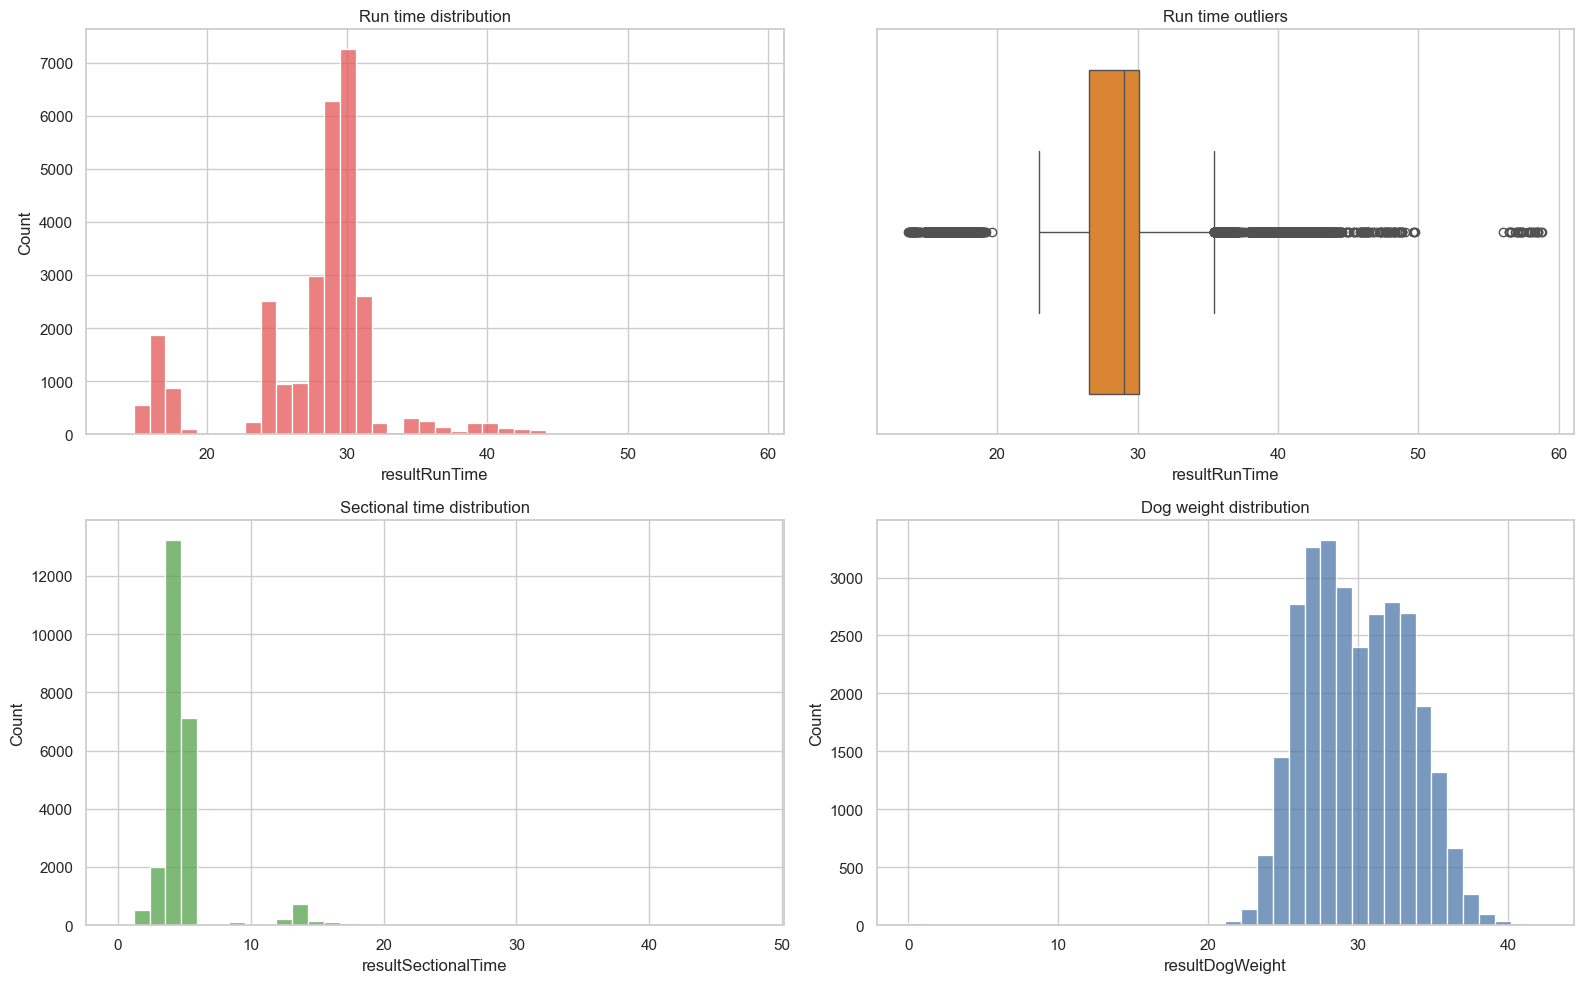

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(run_time.dropna(), bins=40, ax=axes[0, 0], color="#E45756")
axes[0, 0].set_title("Run time distribution")

sns.boxplot(x=run_time.dropna(), ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Run time outliers")

sns.histplot(sectional_time.dropna(), bins=40, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Sectional time distribution")

sns.histplot(dog_weight.dropna(), bins=40, ax=axes[1, 1], color="#4C78A8")
axes[1, 1].set_title("Dog weight distribution")

plt.tight_layout()


In [13]:
anomaly_examples = {
    "result_position_zero": race_info.loc[
        (result_position == 0).fillna(False),
        ["source_file", "trapNumber", "dogId", "dogName", "resultPosition", "resultComment", "resultRunTime"],
    ].head(10),
    "sectional_time_zero": race_info.loc[
        (sectional_time == 0).fillna(False),
        ["source_file", "trapNumber", "dogId", "dogName", "resultSectionalTime", "resultComment"],
    ].head(10),
    "dog_weight_zero": race_info.loc[
        (dog_weight == 0).fillna(False),
        ["source_file", "trapNumber", "dogId", "dogName", "resultDogWeight", "resultComment"],
    ].head(10),
    "run_time_lt_15": race_info.loc[
        (run_time < 15).fillna(False),
        ["source_file", "trapNumber", "dogId", "dogName", "resultRunTime", "resultAdjustedTime"],
    ].head(10),
}

anomaly_examples["result_position_zero"]


,source_file,trapNumber,dogId,dogName,resultPosition,resultComment,resultRunTime
234,725610.csv,1,503278,Live Dangerously,0.0,(NoRace),NaN
235,725610.csv,2,536103,Kennys Hero,0.0,(NoRace),NaN
236,725610.csv,3,549683,Rocky Range,0.0,(NoRace),NaN
237,725610.csv,4,526314,Gurtnacrehy Erza,0.0,(NoRace),NaN
238,725610.csv,5,528488,Good Miss,0.0,(NoRace),NaN
239,725610.csv,6,537388,Pongos Cookie,0.0,(NoRace),NaN
258,385286.csv,1,489834,Our Daisy May,0.0,NaN,NaN
259,385286.csv,2,466331,Bubbly Rose,0.0,NaN,NaN
260,385286.csv,3,471005,Swift Homar,0.0,NaN,NaN
261,385286.csv,4,494687,Confident Aidan,0.0,NaN,NaN


In [14]:
anomaly_examples["sectional_time_zero"]


,source_file,trapNumber,dogId,dogName,resultSectionalTime,resultComment
1283,919278.csv,2,606564,Runaway Havana,0.0,"MsdBrk,Blk&Fell2"
6959,863038.csv,2,610733,Crooks Cookie,0.0,TurnedInTrap
8033,591310.csv,4,501271,Sail On Luckie,0.0,"BCrd&W1,Stpd 3/4"
12569,41970.csv,3,403583,Dower Gypsy,0.0,"Mid,CrdStt,Ck2,(HT)"
12695,4043.csv,2,382228,Shellys Shadow,0.0,TurnedInTrap
16787,582262.csv,1,511648,Mercury Rio,0.0,"Rails,Baulked1,CkFrom2"
19049,760606.csv,2,528808,Valor King,0.0,Fell1
21545,1000416.csv,3,629205,Dubai Kid,0.0,"Crd&Fell1,(TkRec)"


In [15]:
anomaly_examples["dog_weight_zero"]


,source_file,trapNumber,dogId,dogName,resultDogWeight,resultComment
1933,416604.csv,2,473163,Lowgate Belatrix,0.0,"EP,ALd"
1934,416604.csv,1,483375,Hornblower,0.0,"SAw,Crd1"
1935,416604.csv,4,462226,Bang On Giles,0.0,Crd1
1936,416604.csv,5,474272,Westfield Stuner,0.0,"ClrRun,Rls"
1937,416604.csv,3,483523,Devon Diva,0.0,Crd&Ck1
2316,257117.csv,4,435839,Clonmeen Oreo,0.0,"QAw,Crd1,ALd"
2317,257117.csv,6,441722,Lemon Emer,0.0,Bmp1
2318,257117.csv,5,472870,Boherash Melissa,0.0,"Bmp1,Crd2"
2319,257117.csv,1,462384,Phoenix Joanie,0.0,"VSAw,Crd3"
2320,257117.csv,2,477542,Just Timmy,0.0,"MvdOff,Crd1"


In [16]:
anomaly_examples["run_time_lt_15"]


,source_file,trapNumber,dogId,dogName,resultRunTime,resultAdjustedTime
775,1044923.csv,4,601200,Hawkfield Karma,13.76,13.76
776,1044923.csv,1,590813,Great Boss,13.97,13.97
777,1044923.csv,6,612906,Shrewd Mac,14.01,14.01
778,1044923.csv,2,619468,Blueboyu,14.02,14.02
779,1044923.csv,5,622811,Snowy Prince,14.33,14.33
4758,594580.csv,1,522928,Headford Domino,14.98,14.98
5544,566088.csv,6,502044,Philfen Diva,14.81,14.81
5545,566088.csv,2,501736,Lemon Jetson,14.89,14.89
6637,717523.csv,1,542073,Shelone Milo,13.68,13.68
6638,717523.csv,2,539600,Benwell Girl,13.88,13.88


## Recommended cleaning rules

Based on this analysis, the next preprocessing pass should likely treat the following as explicit data-quality cases rather than ordinary numeric values:

- Missing result columns or all-zero `resultPosition` rows probably indicate abandoned, cancelled, or not-yet-run races.
- `resultPosition == 0` should be mapped to a race-status flag, not kept as a normal finishing position.
- `resultSectionalTime == 0` and `resultDogWeight == 0` look like sentinel values in at least some races.
- Very low run times should be validated jointly with `raceDistance`; some may be legitimate sprint races, but they are still tail observations worth monitoring.
- `dogSeason` is too incomplete to use directly without imputation or an explicit missing category.
- `raceTitle` is missing often enough that any text-based feature built on it should be optional.

If you want, the next step can be to turn these checks into reusable validation functions in `src/` so the notebook and feature pipeline share the same rules.
